Problema da Romênia

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [3]:
import networkx as nx

In [4]:

"""1. Construa o grafo inteiro"""

edges = [
    ("Arad","Zerind",75),
    ("Arad","Sibiu",140),
    ("Arad","Timisoara",118),
    ("Zerind","Oradea",71),
    ("Oradea","Sibiu",151),
    ("Timisoara","Lugoj",111),
    ("Lugoj","Mehadia",70),
    ("Mehadia","Dobreta",75),
    ("Dobreta","Craiova",120),
    ("Craiova","Pitesti",138),
    ("Craiova","Rimnicu Vilcea",146),
    ("Rimnicu Vilcea","Sibiu",80),
    ("Rimnicu Vilcea","Pitesti",97),
    ("Sibiu","Fagaras",99),
    ("Fagaras","Bucharest",211),
    ("Pitesti","Bucharest",101),
    ("Bucharest","Giurgiu",90),
    ("Bucharest","Urziceni",85),
    ("Urziceni","Hirsova",98),
    ("Urziceni","Vaslui",142),
    ("Hirsova","Eforie",86),
    ("Vaslui","Iasi",92),
    ("Iasi","Neamt",87),
]

graph = nx.Graph()
graph.add_weighted_edges_from(edges)
graph = nx.Graph()
graph.add_weighted_edges_from(edges)

print(graph)

Graph with 20 nodes and 23 edges


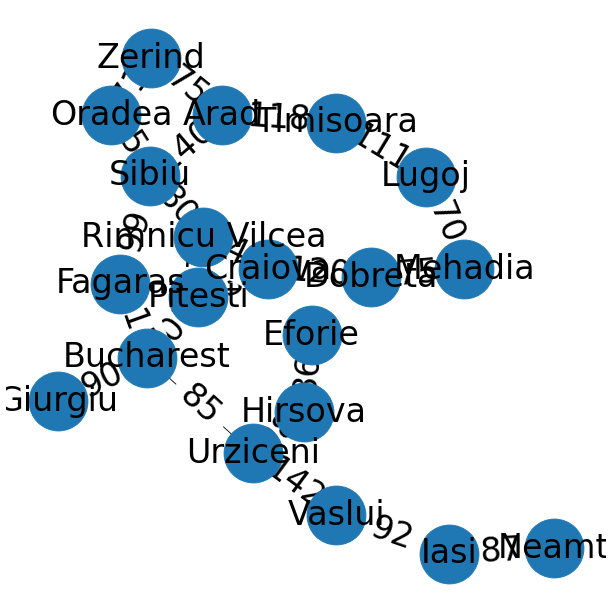

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure(1, figsize=(10, 10), dpi=60)

pos = nx.spring_layout(graph, k=50, iterations=2000, seed=100)
pos = nx.rescale_layout_dict(pos, scale=2000)

nx.draw(graph,
        with_labels=True,
        node_size=5000,
        font_color='black',
        font_size=40,
        pos=pos
        )

edge_labels = dict([((n1, n2), d['weight']) for n1, n2, d in graph.edges(data=True)])
nx.draw_networkx_edge_labels(graph,
                             pos,
                             font_size=40,
                             edge_labels=edge_labels)
plt.show()

In [6]:
from metaheuristics import *

start_node = 'Arad'

visited_nodes = [start_node]
unvisited_nodes = list(graph.nodes)
unvisited_nodes.remove(start_node)

inital_state = RomaniaState(visited_nodes=visited_nodes,
                     unvisited_nodes=unvisited_nodes)
cost = 0

node = Node(state=inital_state, parent=None, action=None, path_cost=cost)
problem = RomaniaProblem(initial_node=node, graph=graph)

node = best_first_search(problem=problem)

print(f'cost: {node.path_cost} \n solution: {node.state.visited_nodes}')


Shorter path Bucharest 418 < 450
cost: 418 
 solution: ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']


In [16]:
print(graph.has_edge("Arad", "Sibiu"))      # True
print(graph.has_edge("Sibiu", "Arad"))     

True
True


In [8]:
path = nx.shortest_path(graph, 
                        source="Arad", 
                        target="Bucharest", 
                        weight="weight")

cost = nx.shortest_path_length(graph, 
                               source="Arad", 
                               target="Bucharest", 
                               weight="weight")

print("Path:", path)
print("Cost:", cost)

Path: ['Arad', 'Sibiu', 'Rimnicu Vilcea', 'Pitesti', 'Bucharest']
Cost: 418
